In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import sys, string, random
from datetime import datetime
from omegaconf import OmegaConf
# import wandb
import torch
import lightning as L
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from monai.networks.nets import UNet

sys.path.append('../')
from data_utils import MNMv2DataModule
from unet import LightningSegmentationModel
import matplotlib.pyplot as plt
from torch.distributions import Categorical

In [3]:
# load configs
mnmv2_config   = OmegaConf.load('../../configs/mnmv2.yaml')
unet_config    = OmegaConf.load('../../configs/monai_unet.yaml')
trainer_config = OmegaConf.load('../../configs/unet_trainer.yaml')

In [4]:
# init datamodule
datamodule = MNMv2DataModule(
    data_dir=mnmv2_config.data_dir,
    vendor_assignment=mnmv2_config.vendor_assignment,
    batch_size=mnmv2_config.batch_size,
    binary_target=mnmv2_config.binary_target,
    non_empty_target=mnmv2_config.non_empty_target,
)

In [5]:
# init model
unet = UNet(
    spatial_dims=unet_config.spatial_dims,
    in_channels=unet_config.in_channels,
    out_channels=unet_config.out_channels,
    channels=[unet_config.n_filters_init * 2 ** i for i in range(unet_config.depth)],
    strides=[2] * (unet_config.depth - 1),
    num_res_units=4
)

model = LightningSegmentationModel(
    model=unet,
    binary_target=True if unet_config.out_channels == 1 else False,
    lr=unet_config.lr,
    patience=unet_config.patience,
    cfg={
        'dataset': OmegaConf.to_container(mnmv2_config),
        'unet': OmegaConf.to_container(unet_config),
        'trainer': OmegaConf.to_container(trainer_config)
    }
)

# Training (DO NOT RUN)

In [6]:
# infered variable
patience = unet_config.patience * 2

now = datetime.now()
filename = 'mnmv2-' + now.strftime("%H-%M_%d-%m-%Y")

# init trainer
if trainer_config.logging:
    wandb.finish()
    logger = WandbLogger(
        project="lightning", 
        log_model=True, 
        name=filename
    )
else:
    logger = None

# trainer
trainer = L.Trainer(
    limit_train_batches=trainer_config.limit_train_batches,
    max_epochs=trainer_config.max_epochs,
    logger=logger,
    callbacks=[
        EarlyStopping(
            monitor=trainer_config.early_stopping.monitor, 
            mode=trainer_config.early_stopping.mode, 
            patience=patience
        ),
        ModelCheckpoint(
            dirpath=trainer_config.model_checkpoint.dirpath,
            filename=filename,
            save_top_k=trainer_config.model_checkpoint.save_top_k, 
            monitor=trainer_config.model_checkpoint.monitor,
        )
    ],
    precision='16-mixed',
    gradient_clip_val=0.5,
    devices=[7]
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [7]:
trainer.fit(model, datamodule=datamodule)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: jlennartz. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | UNet       | 794 K  | train
1 | loss  | DiceCELoss | 0      | train
---------------------------------------------
794 K     Trainable params
0         Non-trainable params
794 K     Total params
3.178     Total estimated model params size (MB)
163       Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 50/50 [00:08<00:00,  6.08it/s, v_num=8psl]      

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 50/50 [00:08<00:00,  6.05it/s, v_num=8psl]


# Okay you're good now

In [6]:
checkpoint_path = '../../checkpoints/mnmv2-11-52_29-10-2024.ckpt'

load_as_lightning_module = False
load_as_pytorch_module = True

if load_as_lightning_module:
    unet_config    = OmegaConf.load('../../configs/monai_unet.yaml')
    unet = UNet(
        spatial_dims=unet_config.spatial_dims,
        in_channels=unet_config.in_channels,
        out_channels=unet_config.out_channels,
        channels=[unet_config.n_filters_init * 2 ** i for i in range(unet_config.depth)],
        strides=[2] * (unet_config.depth - 1),
        num_res_units=4
    )
    model = LightningSegmentationModel.load_from_checkpoint(
        checkpoint_path,
        map_location=torch.device("cpu"),
        model=unet,
        binary_target=True if unet_config.out_channels == 1 else False,
        lr=unet_config.lr,
        patience=unet_config.patience,
        # cfg=OmegaConf.to_container(unet_config)
    )

elif load_as_pytorch_module:
    checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))
    model_state_dict = checkpoint['state_dict']
    model_state_dict = {k.replace('model.model.', 'model.'): v for k, v in model_state_dict.items() if k.startswith('model.')}
    model_config = checkpoint['hyper_parameters']['cfgs']

    

    unet = UNet(
        spatial_dims=model_config['unet']['spatial_dims'],
        in_channels=model_config['unet']['in_channels'],
        out_channels=model_config['unet']['out_channels'],
        channels=[model_config['unet']['n_filters_init'] * 2 ** i for i in range(model_config['unet']['depth'])],
        strides=[2] * (model_config['unet']['depth'] - 1),
        num_res_units=4
    )

    unet.load_state_dict(model_state_dict)

/tmp/ipykernel_2319078/507692606.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))


In [7]:
datamodule.setup('test')
test_loader = datamodule.test_dataloader()

for i, batch in enumerate(test_loader):
    if i == 3:
        break

img = batch['input']
targets = batch['target']

img.shape

torch.Size([32, 1, 256, 256])

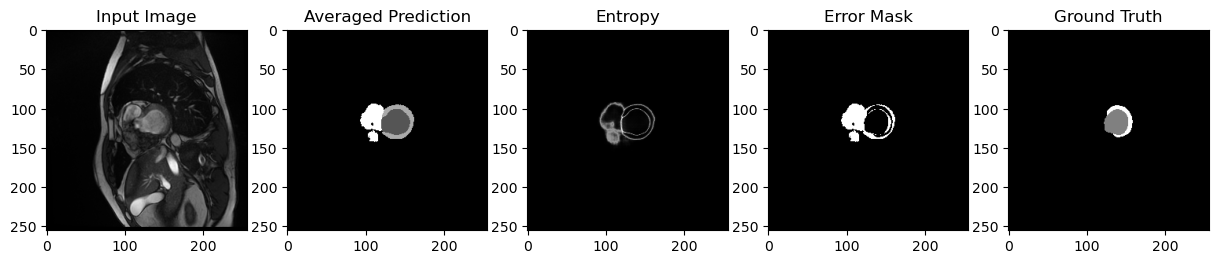

In [26]:
from torch.distributions import Categorical

datamodule.setup('test')
test_loader = datamodule.test_dataloader()

for i, batch in enumerate(test_loader):
    if i == 3:
        break

img = batch['input']
targets = batch['target']


# Select an image from the batch
image_idx = 4
image = img[image_idx:image_idx+1].cuda()

# Move the model to GPU
unet = unet.cuda()

# Number of stochastic forward passes
num_samples = 300

# Collect predictions
predictions = []
unet.eval()
softmax = torch.nn.Softmax(dim=1)
with torch.no_grad():
    for _ in range(num_samples):
        pred = unet(image)
        prob = softmax(pred)
        predictions.append(prob.cpu())

# Stack predictions to get a tensor of shape [num_samples, C, H, W]
predictions = torch.stack(predictions, dim=0)

# Average predictions
avg_predictions = torch.mean(predictions, dim=0)

# Calculate entropy

entropy = Categorical(probs=avg_predictions.moveaxis(1,3)).entropy()

error_mask = (avg_predictions[0].cpu().argmax(0) != targets[image_idx, 0].cpu())

# error_mask = predicted_probs[idx].cpu().argmax(0) != targets[idx, 0].cpu()

# Plot the results
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
ax[0].imshow(image[0, 0].cpu(), cmap='gray')
ax[0].set_title('Input Image')
ax[1].imshow(avg_predictions[0].argmax(0).cpu(), cmap='gray')
ax[1].set_title('Averaged Prediction')
ax[2].imshow(entropy[0], cmap='gray')
ax[2].set_title('Entropy')
ax[3].imshow(error_mask, cmap='gray')
ax[3].set_title('Error Mask')
ax[4].imshow(targets[image_idx, 0].cpu(), cmap='gray')
ax[4].set_title('Ground Truth')

plt.show()

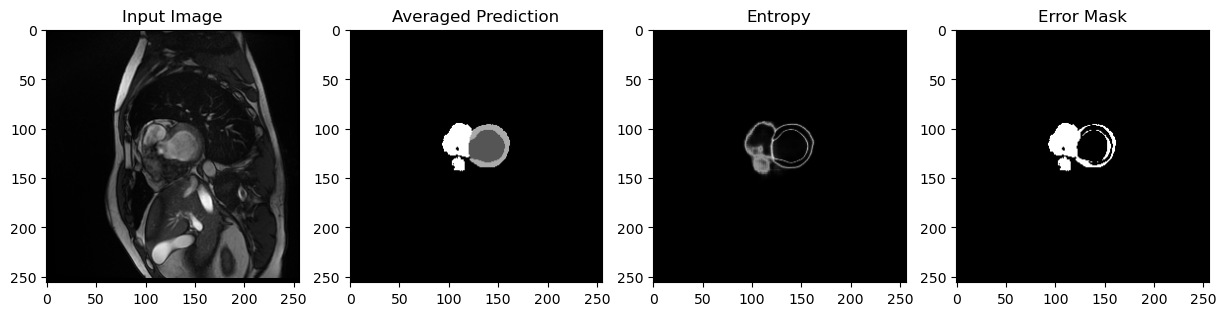

In [32]:
# Plot the results
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(image[0, 0].cpu(), cmap='gray')
ax[0].set_title('Input Image')
ax[1].imshow(avg_predictions[0].argmax(0).cpu(), cmap='gray')
ax[1].set_title('Averaged Prediction')
ax[2].imshow(entropy[0], cmap='gray')
ax[2].set_title('Entropy')
ax[3].imshow(error_mask, cmap='gray')
ax[3].set_title('Error Mask')

plt.show()

In [33]:
entropy.shape

torch.Size([1, 256, 256])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2987153768539429..1.9817290115356445].


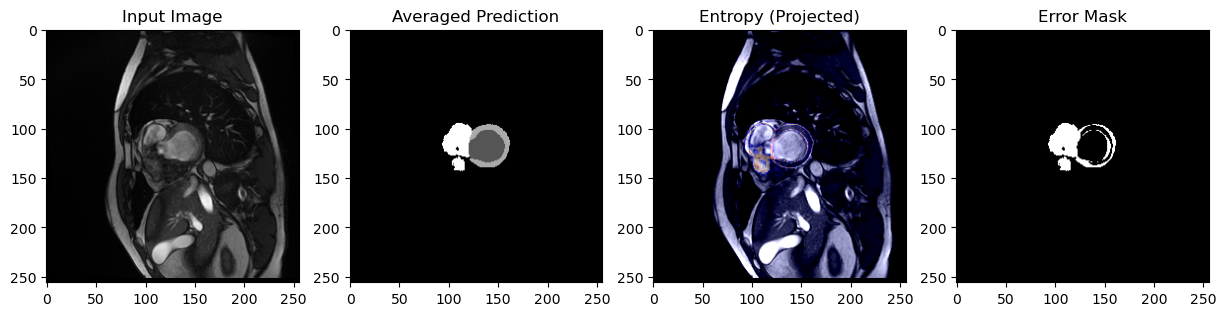

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Assume `image`, `entropy` are PyTorch tensors
input_image = image[0, 0].cpu().numpy()  # Extract first batch, first channel
entropy_map = entropy[0].cpu().numpy()  # Extract first batch

# Normalize entropy for colormap
entropy_normalized = (entropy_map - np.min(entropy_map)) / (np.max(entropy_map) - np.min(entropy_map) + 1e-8)

# Create a colored entropy map using seismic colormap
entropy_colormap = plt.cm.seismic(entropy_normalized)[..., :3]  # Remove alpha channel

# Create an RGB version of the grayscale input image
input_image_rgb = np.stack([input_image] * 3, axis=-1)  # Convert grayscale to RGB

# Blend the entropy map with the input image
alpha = (entropy_map > 0).astype(float) * 0.6  # Only show entropy regions with 60% transparency
blended_image = (1 - alpha[..., None]) * input_image_rgb + alpha[..., None] * entropy_colormap

# Plot the results
fig, ax = plt.subplots(1, 4, figsize=(15, 5))

ax[0].imshow(input_image, cmap='gray')
ax[0].set_title('Input Image')

ax[1].imshow(avg_predictions[0].argmax(0).cpu(), cmap='gray')
ax[1].set_title('Averaged Prediction')

ax[2].imshow(blended_image)  # Show blended image with entropy overlay
ax[2].set_title('Entropy (Projected)')

ax[3].imshow(error_mask.cpu(), cmap='gray')
ax[3].set_title('Error Mask')

plt.show()


In [ ]:
import pandas as pd


def compute_entropy_dataframe(unet, datamodule, num_samples=300):
    datamodule.setup('test')
    test_loader = datamodule.test_dataloader()
    
    entropies = []
    unet = unet.cuda()
    unet.eval()
    softmax = torch.nn.Softmax(dim=1)
    
    with torch.no_grad():

        for i, batch in enumerate(test_loader):
            img_batch = batch['input'].cuda()
            
            for image_idx in range(img_batch.shape[0]):
                image = img_batch[image_idx:image_idx+1]
                predictions = []
                
                for _ in range(num_samples):
                    pred = unet(image)
                    prob = softmax(pred)
                    predictions.append(prob.cpu())
                
                predictions = torch.stack(predictions, dim=0)
                avg_predictions = torch.mean(predictions, dim=0)
                entropy = Categorical(probs=avg_predictions.moveaxis(1,3)).entropy()
                avg_entropy = entropy.mean().item()
                
                entropies.append({'batch_index': i,'image_index': image_idx, 'avg_entropy': avg_entropy})
        
            if i==1:
                break
    
    df = pd.DataFrame(entropies)
    df = df.sort_values(by='avg_entropy', ascending=False)
    return df


df = compute_entropy_dataframe(unet, datamodule, num_samples=1)
df.head()


,batch_index,image_index,avg_entropy
56,1,24,0.021525
60,1,28,0.014017
35,1,3,0.013462
14,0,14,0.013023
17,0,17,0.008647


In [13]:
datamodule.setup('test')
test_loader = datamodule.test_dataloader()

In [ ]:
import torch
import pandas as pd
from torch.distributions import Categorical
import matplotlib.pyplot as plt

def compute_entropy_dataframe(unet, datamodule, num_samples=300):

    
    entropies = []
    unet = unet.cuda()
    # Keep the model in evaluation mode to disable dropout
    unet.eval()
    softmax = torch.nn.Softmax(dim=1)
    
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            img_batch = batch['input'].cuda()
            
            # Process the entire batch in parallel
            predictions = torch.tensor([])

            pred = unet(img_batch)
            prob = softmax(pred)
            predictions = prob.cpu()
            
            # predictions = torch.stack(predictions, dim=0)
            # avg_predictions = torch.mean(predictions, dim=0)
            entropy = Categorical(probs=predictions.moveaxis(1, 3)).entropy()
            
            for image_idx in range(img_batch.shape[0]):
                avg_entropy = entropy[image_idx].mean().item()
                entropies.append({'batch_index': i, 'image_index': image_idx, 'avg_entropy': avg_entropy})
        
            if i == 1:
                break
    
    df = pd.DataFrame(entropies)
    df = df.sort_values(by='avg_entropy', ascending=False)
    return df

# Example usage
df = compute_entropy_dataframe(unet, datamodule, num_samples=100)  # Reduced num_samples for faster computation
print(df.head())


    batch_index  image_index  avg_entropy
56            1           24     0.021525
60            1           28     0.014017
35            1            3     0.013462
14            0           14     0.013023
17            0           17     0.008647


In [ ]:
# To be worked with

def compute_entropy_dataframe(unet, datamodule):
    
    entropies = []
    unet = unet.cuda()
    unet.eval()
    softmax = torch.nn.Softmax(dim=1)
    
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            img_batch = batch['input'].cuda()
            
            # Compute a single prediction per image instead of looping multiple times
            pred = unet(img_batch)
            prob = softmax(pred)
            entropy = Categorical(probs=prob.moveaxis(1, 3)).entropy()
            # Compue other uncertainty measures here
            
            batch_indices = torch.full((img_batch.shape[0],), i, dtype=torch.int)
            image_indices = torch.arange(img_batch.shape[0])
            avg_entropies = entropy.mean(dim=(1, 2)).tolist()
            # add other uncertainty measures here
            
            entropies.extend(
                zip(batch_indices.tolist(), image_indices.tolist(), avg_entropies)
            )
            

    
    df = pd.DataFrame(entropies, columns=['batch_index', 'image_index', 'avg_entropy'])
    df = df.sort_values(by='avg_entropy', ascending=False)
    return df

df = compute_entropy_dataframe(unet, datamodule)
print(df.head())

     batch_index  image_index  avg_entropy
326           10            6     0.100463
339           10           19     0.095549
340           10           20     0.092589
341           10           21     0.090957
328           10            8     0.086969


In [10]:
import pandas as pd


def compute_entropy_dataframe(unet, datamodule, num_samples=300):
    datamodule.setup('test')
    test_loader = datamodule.test_dataloader()
    
    entropies = []
    unet = unet.cuda()
    unet.eval()
    softmax = torch.nn.Softmax(dim=1)
    
    with torch.no_grad():
        data_in = torch.tensor([])

        for i, batch in enumerate(test_loader):
            data_in = torch.cat((data_in, batch['input']), dim=0)

            predictions = unet(data_in.cuda())
            prob = softmax(predictions)
            entropy = Categorical(probs=prob.moveaxis(1,3)).entropy()
            avg_entropy = entropy.mean().item()
            entropies.append({'batch_index': i, 'avg_entropy': avg_entropy})

            if i==1:
                break
    
    df = pd.DataFrame(entropies)
    df = df.sort_values(by='avg_entropy', ascending=False)
    return df


df = compute_entropy_dataframe(unet, datamodule, num_samples=1)
df.head()


,batch_index,avg_entropy
1,1,0.005360
0,0,0.004866


Best threshold: 0.041690848767757416
Least discrepancy: 1146


Text(0.5, 1.0, 'Error Mask')

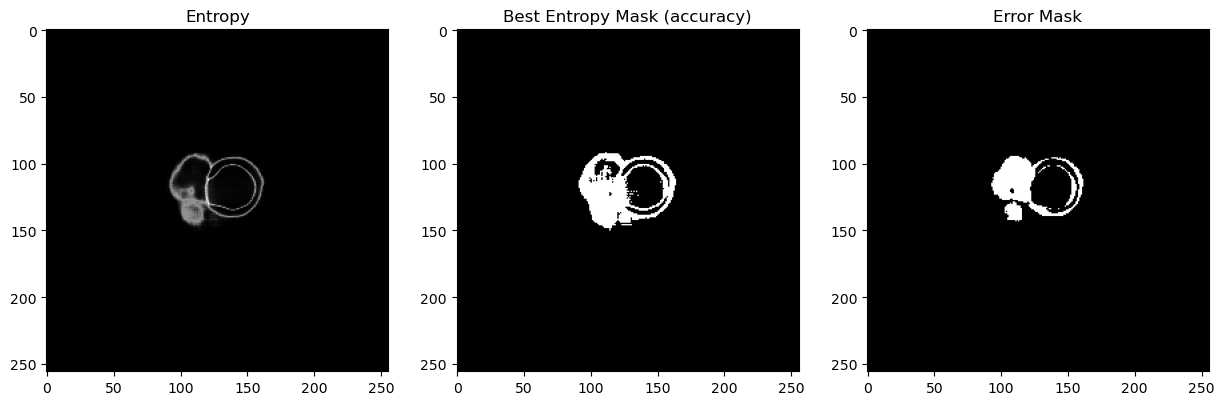

In [64]:
# Calculate the best threshold by minimizing the discrepancy between the error mask and the entropy mask

min_entropy = entropy.min()
max_entropy = entropy.max()

threshold = entropy.mean()
entropy_mask = entropy > threshold

best_threshold = threshold
least_discrepancy = (entropy_mask != error_mask).sum().item()

thresholds = torch.linspace(min_entropy, max_entropy, steps=10000)
current_entropy_masks = entropy.unsqueeze(0) > thresholds.unsqueeze(1).unsqueeze(2).unsqueeze(3)
discrepancies = (current_entropy_masks != error_mask.unsqueeze(0)).sum(dim=(1, 2, 3))
least_discrepancy_idx = discrepancies.argmin()
least_discrepancy = discrepancies[least_discrepancy_idx].item()
best_threshold = thresholds[least_discrepancy_idx]
best_entropy_mask = current_entropy_masks[least_discrepancy_idx]

print(f'Best threshold: {best_threshold}')
print(f'Least discrepancy: {least_discrepancy}')


fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(entropy[0], cmap='gray')
ax[0].set_title('Entropy')
ax[1].imshow(best_entropy_mask[0], cmap='gray')
ax[1].set_title('Best Entropy Mask (accuracy)')
ax[2].imshow(error_mask, cmap='gray')
ax[2].set_title('Error Mask')


Best threshold: 0.508345365524292
Best F1 score: 0.6651363372802734


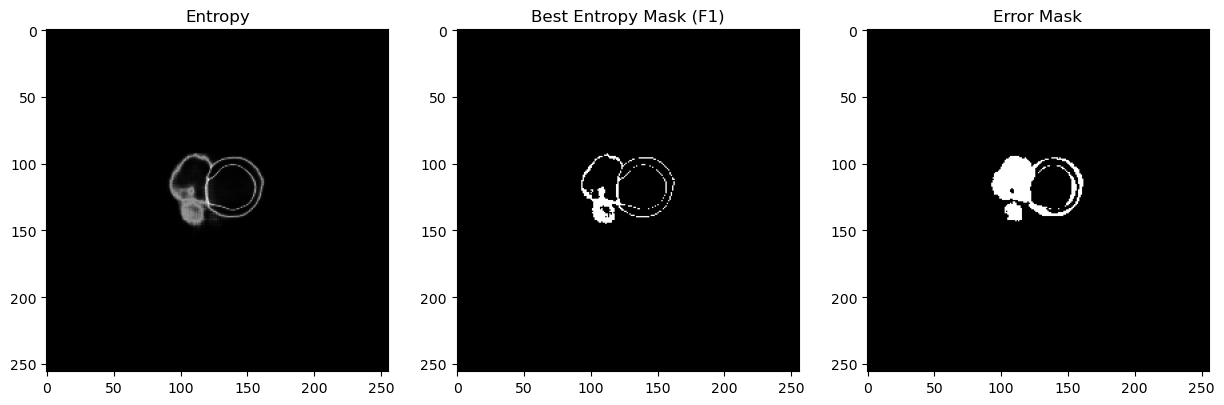

In [66]:
from torchmetrics.functional import precision_recall_curve

# Flatten the error mask and entropy tensor
error_mask_flat = error_mask.flatten()
entropy_flat = entropy.flatten()

# Calculate precision and recall for different thresholds
precision, recall, thresholds = precision_recall_curve(entropy_flat, error_mask_flat, task='binary')

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Get the index of the best threshold (highest F1 score)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

print(f'Best threshold: {best_threshold}')
print(f'Best F1 score: {f1_scores[best_threshold_idx]}')

# Apply the best threshold to get the best entropy mask
best_entropy_mask = entropy > best_threshold

# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(entropy[0], cmap='gray')
ax[0].set_title('Entropy')
ax[1].imshow(best_entropy_mask[0], cmap='gray')
ax[1].set_title('Best Entropy Mask (F1)')
ax[2].imshow(error_mask, cmap='gray')
ax[2].set_title('Error Mask')

plt.show()


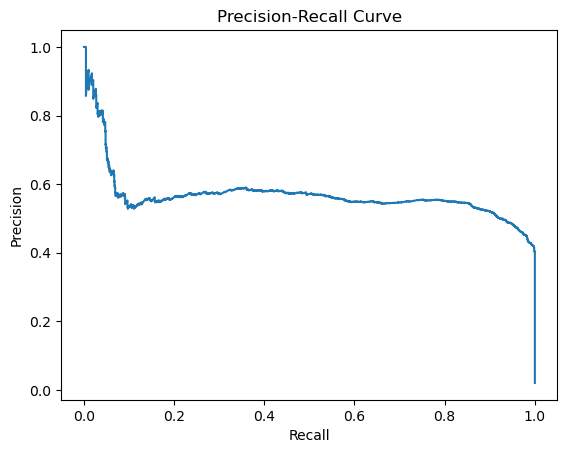

In [63]:
# Plot the precision-recall curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


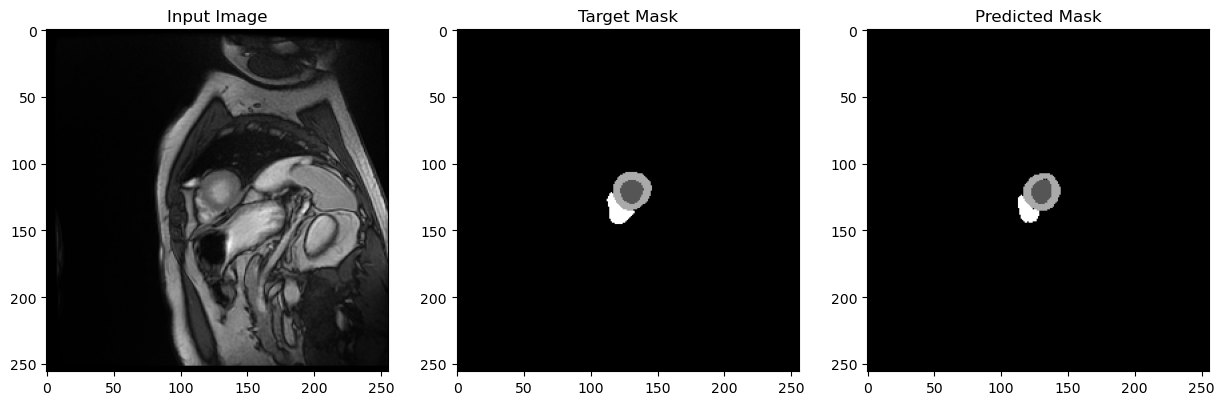

In [15]:
unet.eval()
with torch.no_grad():
    preds = unet(img).cpu()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img[0, 0], cmap='gray')
ax[0].set_title('Input Image')
ax[1].imshow(targets[0, 0], cmap='gray')
ax[1].set_title('Target Mask')
ax[2].imshow(preds[0].argmax(0), cmap='gray')
ax[2].set_title('Predicted Mask')

plt.show()

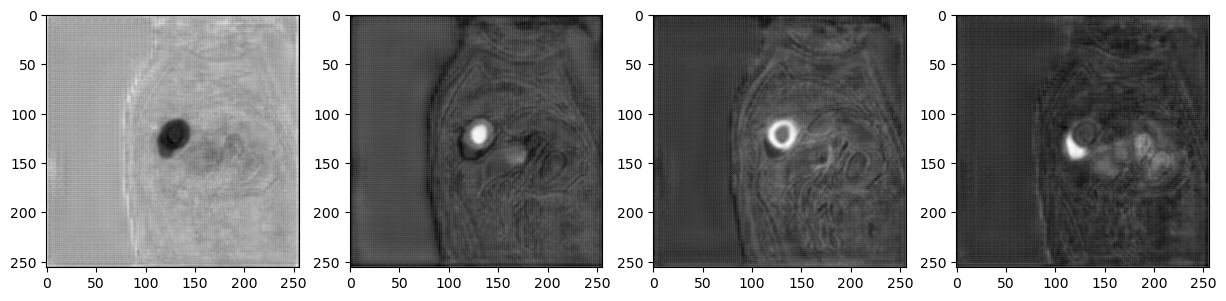

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(preds[0, 0], cmap='gray')
ax[1].imshow(preds[0, 1], cmap='gray')
ax[2].imshow(preds[0, 2], cmap='gray')
ax[3].imshow(preds[0, 3], cmap='gray')


In [36]:
from copy import deepcopy
import matplotlib.pyplot as plt
from torch.distributions import Categorical

unet = deepcopy(model.model).cuda()

datamodule.setup('fit')
train_generator = datamodule.train_dataloader()
batch = next(train_generator)

softmax = torch.nn.Softmax(dim=1)

inputs = batch['data']
targets = batch['target']

unet.eval()
with torch.no_grad():
    outputs = unet(inputs.cuda()).cpu()
    
predicted_probs = softmax(outputs)



In [30]:
test = predicted_probs.moveaxis(1, 3)

test.shape

torch.Size([32, 256, 256, 4])

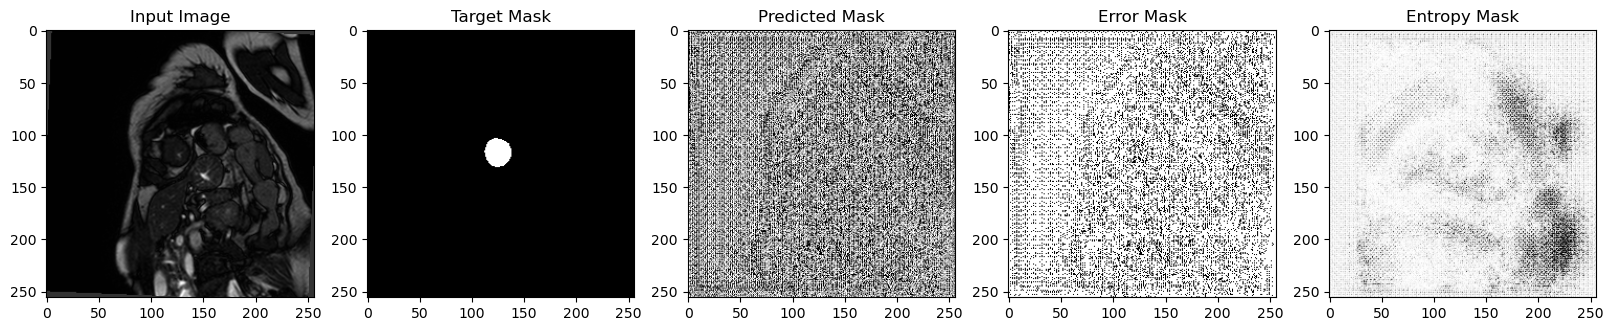

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

idx = 4

# Input Image
axes[0].imshow(inputs[idx, 0].cpu(), cmap='gray')
axes[0].set_title('Input Image')

# Target Mask
axes[1].imshow(targets[idx, 0].cpu(), cmap='gray')
axes[1].set_title('Target Mask')

# Predicted Mask
axes[2].imshow(outputs[idx].cpu().argmax(0), cmap='gray')
axes[2].set_title('Predicted Mask')

# Error Mask
error_mask = predicted_probs[idx].cpu().argmax(0) != targets[idx, 0].cpu()
axes[3].imshow(error_mask, cmap='gray')
axes[3].set_title('Error Mask')

# Entropy Mask
pred_entrp = Categorical(probs = predicted_probs.moveaxis(1, 3)).entropy()
axes[4].imshow(pred_entrp[0], cmap='gray')
axes[4].set_title('Entropy Mask')

plt.show()

# axes[2].imshow(predicted_probs[idx].cpu().argmax(0)!= targets[idx, 0].cpu(), cmap='seismic')



In [ ]:
import torch

# Save tensors to files
torch.save(inputs, 'inputs.pt')
torch.save(targets, 'targets.pt')
torch.save(predicted_probs, 'predicted_probs.pt')
torch.save(pred_entrp, 'pred_entrp.pt')
torch.save(outputs, 'outputs.pt')

# Function to download files
import requests

def download_image(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as file:
            file.write(response.content)
        print(f"Image successfully downloaded: {save_path}")
    else:
        print(f"Failed to download image. Status code: {response.status_code}")

def download_file(file_path, save_path):
    with open(file_path, 'rb') as file:
        content = file.read()
    with open(save_path, 'wb') as file:
        file.write(content)
    print(f"File successfully downloaded: {save_path}")

# Example usage
download_file('inputs.pt', 'local_inputs.pt')
download_file('targets.pt', 'local_targets.pt')
download_file('predicted_probs.pt', 'local_predicted_probs.pt')
download_file('pred_entrp.pt', 'local_pred_entrp.pt')
download_file('outputs.pt', 'local_outputs.pt')


AttributeError: 'numpy.ndarray' object has no attribute 'set_title'

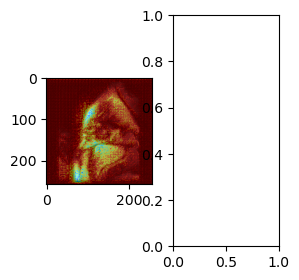

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(3,3))
ax[0].imshow(inputs[idx, 0].cpu(), cmap='gray')
ax[0].imshow(pred_entrp[idx].detach().cpu(), cmap='jet', alpha=0.5)
ax[0].set_title('Input Image with Entropy Mask Overlay')
ax[1].imshow(, cmap='jet')
plt.show()

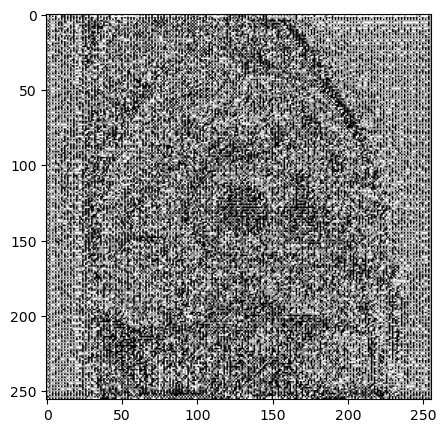

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(outputs[idx].argmax(0), cmap='gray') # What are the other 3 channels?

In [40]:
# Assume `predictions` is a list of segmentation probability maps with shape [B, C, H, W]
# Each element in `predictions` corresponds to one stochastic forward pass.

predictions = torch.stack(predicted_probs, dim=0)  # Shape: [N, B, C, H, W], N = number of samples

# Compute pixel-wise variance across N samples
variance = torch.var(predictions, dim=0)  # Shape: [B, C, H, W]

# Example: Mean variance across spatial dimensions
mean_variance = torch.mean(variance)
print("Mean Variance:", mean_variance.item())


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor